In [1]:
import pandas as pd
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
import numpy as np
import matplotlib.pyplot as plt
import pmdarima as pm
import seaborn as sns
from matplotlib.pyplot import figure
import numpy as np
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import math
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d.axes3d import Axes3D

In [5]:
c1=pd.read_csv(r'C:\Users\Goku\Desktop\BBDA\protergia-consumption-analysis\Data\1_updated.csv',sep =';', low_memory=False)
c1

,ΗΜΕΡΟΜΗΝΙΑ ΜΕΤΡΗΣΗΣ,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15,Q16,Q17,Q18,Q19,Q20,Q21,Q22,Q23,Q24,Q25,Q26,Q27,Q28,Q29,Q30,Q31,Q32,Q33,Q34,Q35,Q36,Q37,Q38,Q39,Q40,Q41,Q42,Q43,Q44,Q45,Q46,Q47,Q48,Q49,Q50,Q51,Q52,Q53,Q54,Q55,Q56,Q57,Q58,Q59,Q60,Q61,Q62,Q63,Q64,Q65,Q66,Q67,Q68,Q69,Q70,Q71,Q72,Q73,Q74,Q75,Q76,Q77,Q78,Q79,Q80,Q81,Q82,Q83,Q84,Q85,Q86,Q87,Q88,Q89,Q90,Q91,Q92,Q93,Q94,Q95,Q96,ΠΟΛΗ,ΤΚ
0,19/12/2019,321,327,314,326,325,315,324,329,310,322,321,318,317,321,313,309,328,307,327,316,313,330,322,333,335,326,319,331,327,328,313,320,336,316,320,333,315,337,342,339,337,335,321,343,341,335,334,325,342,344,321,329,334,345,337,346,349,350,341,342,340,335,333,339,330,329,343,308,306,307,317,315.0,304,313,294,307,311,308,314,298,306,303,300,299,326,306,303,303,315,325,322,320,308,322,312,314,ΜΑΛΑΜΑΤΑ ΔΩΡΙΔΟΣ,33056.0
1,20/12/2019,325,328,316,327,331,332,317,334,320,325,327,309,321,322,311,329,323,307,326,312,324,312,319,317,333,321,345,343,334,327,330,317,339,337,336,328,327,308,309,324,308,326,322,324,312,330,310,317,318,333,327,322,323,331,309,310,327,326,336,322,336,329,330,339,338,323,334,329,336,323,332,339.0,328,334,332,332,339,324,335,326,322,329,329,319,335,331,319,335,328,335,326,331,328,310,339,330,NaN,NaN
2,21/12/2019,337,320,344,320,337,319,339,326,331,319,337,328,329,337,324,326,326,339,319,338,324,326,328,255,201,205,205,205,198,206,204,204,195,201,202,195,196,205,204,200,205,198,200,206,202,197,197,198,203,202,204,202,201,205,208,205,203,207,204,206,200,203,207,202,202,204,201,205,203,200,205,203.0,200,205,200,204,202,204,205,203,206,206,201,204,203,196,203,132,119,126,122,122,96,101,107,96,NaN,NaN
3,22/12/2019,104,103,103,100,101,104,105,105,91,94,102,103,107,89,107,105,102,95,86,97,94,96,101,69,18,11,8,9,8,8,8,8,9,8,9,10,11,11,11,11,10,10,10,9,8,8,9,7,20,79,62,56,45,41,46,44,59,78,81,83,80,84,79,84,80,80,85,80,82,86,82,87.0,81,79,83,60,96,90,87,88,76,77,87,78,81,86,80,89,82,92,84,87,89,86,87,87,NaN,NaN
4,23/12/2019,90,84,89,85,86,86,88,87,85,111,99,87,88,89,89,91,106,176,192,179,141,139,140,148,205,264,265,265,283,276,272,282,277,283,285,273,274,290,273,277,285,291,312,281,287,290,299,303,292,282,282,285,291,288,289,304,286,296,296,298,301,319,285,291,292,304,301,292,303,300,291,295.0,283,285,302,286,285,293,284,278,284,286,273,289,298,284,290,294,279,287,298,279,300,287,291,290,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5232,13/8/2020,385,385,380,390,375,383,377,376,374,376,376,380,365,364,376,363,375,373,372,372,374,377,371,373,376,376,379,371,380,376,379,385,385,384,376,373,379,383,388,403,391,386,398,383,391,391,383,384,385,401,400,398,392,405,407,407,407,414,419,413,409,417,419,418,422,421,413,409,411,412,408,408.0,406,405,406,397,400,400,400,391,395,390,390,391,389,390,387,388,392,386,387,383,386,382,372,384,NaN,NaN
5233,14/8/2020,388,392,394,395,389,394,391,389,388,386,387,389,389,387,388,385,204,257,334,367,366,373,371,367,368,375,376,378,373,367,362,358,363,375,360,371,374,371,368,374,364,367,374,381,377,384,381,382,383,380,383,376,374,384,384,381,384,385,384,383,383,384,376,381,377,381,380,377,378,376,377,379.0,375,374,373,374,374,374,366,368,364,366,364,372,376,360,373,161,54,45,25,24,25,24,26,26,NaN,NaN
5234,15/8/2020,25,27,25,32,40,40,32,25,26,25,25,26,32,40,39,35,25,25,25,25,27,40,39,39,27,28,26,26,25,38,39,40,31,26,24,25,25,34,54,35,25,26,26,26,26,39,48,49,33,35,80,85,83,77,74,72,70,67,65,65,63,80,86,70,63,64,65,68,66,62,57,56.0,60,63,61,61,74,73,55,59,56,50,51,50,49,51,51,51,48,48,47,47,59,62,58,49,NaN,NaN
5235,16/8/2020,50,50,48,48,45,43,42,42,44,44,46,47,50,57,53,36,26,34,42,42,43,42,42,40,40,35,25,23,27,45,42,52,55,50,41,41,39,38,40,4

In [6]:
c1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5237 entries, 0 to 5236
Data columns (total 99 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ΗΜΕΡΟΜΗΝΙΑ ΜΕΤΡΗΣΗΣ  5237 non-null   object 
 1   Q1                   5237 non-null   int64  
 2   Q2                   5237 non-null   int64  
 3   Q3                   5237 non-null   int64  
 4   Q4                   5237 non-null   int64  
 5   Q5                   5237 non-null   int64  
 6   Q6                   5237 non-null   int64  
 7   Q7                   5237 non-null   int64  
 8   Q8                   5237 non-null   int64  
 9   Q9                   5237 non-null   int64  
 10  Q10                  5237 non-null   int64  
 11  Q11                  5237 non-null   int64  
 12  Q12                  5237 non-null   int64  
 13  Q13                  5237 non-null   int64  
 14  Q14                  5237 non-null   int64  
 15  Q15                  5237 non-null   i

In [7]:
c1['Q72'] = c1['Q72'].astype(np.int64)

In [8]:
print(c1.shape)
c1 = c1.drop_duplicates()
c1 = c1.drop(['ΠΟΛΗ', 'ΤΚ'],axis =1)
c1.shape

(5237, 99)


(1259, 97)

In [9]:
c1.insert(1, 'date', pd.to_datetime(c1['ΗΜΕΡΟΜΗΝΙΑ ΜΕΤΡΗΣΗΣ'],format = '%d/%m/%Y'))
del c1['ΗΜΕΡΟΜΗΝΙΑ ΜΕΤΡΗΣΗΣ']

In [10]:
c1 = c1.reset_index(drop = True)

In [11]:
c1 = c1.sort_values('date')

In [12]:
c1 = c1.groupby('date', group_keys=False).apply(lambda x: x.loc[x.Q1.idxmax()])

In [13]:
df = c1.drop('date', axis =1)

In [16]:
df

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15,Q16,Q17,Q18,Q19,Q20,Q21,Q22,Q23,Q24,Q25,Q26,Q27,Q28,Q29,Q30,Q31,Q32,Q33,Q34,Q35,Q36,Q37,Q38,Q39,Q40,Q41,Q42,Q43,Q44,Q45,Q46,Q47,Q48,Q49,Q50,Q51,Q52,Q53,Q54,Q55,Q56,Q57,Q58,Q59,Q60,Q61,Q62,Q63,Q64,Q65,Q66,Q67,Q68,Q69,Q70,Q71,Q72,Q73,Q74,Q75,Q76,Q77,Q78,Q79,Q80,Q81,Q82,Q83,Q84,Q85,Q86,Q87,Q88,Q89,Q90,Q91,Q92,Q93,Q94,Q95,Q96
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-03-02,272,261,277,270,263,280,268,265,267,273,270,275,269,268,282,269,266,275,289,300,283,290,281,280,285,278,285,288,299,298,292,287,296,294,276,284,281,294,299,282,298,294,287,289,298,301,300,281,287,293,292,284,287,281,270,288,289,284,264,263,281,270,263,275,285,270,278,274,280,271,267,263,260,252,257,263,263,254,261,263,262,255,270,265,267,263,252,258,247,250,240,243,246,245,249,249
2018-03-03,246,243,246,238,248,250,248,243,251,241,241,250,252,248,245,238,242,245,248,248,241,242,246,195,196,205,205,203,199,189,201,189,193,197,187,191,194,197,197,200,188,198,193,191,188,191,187,189,197,195,199,193,200,194,193,195,198,193,196,205,195,193,196,194,191,192,192,191,189,184,184,180,181,182,185,184,178,179,180,183,183,201,195,189,195,188,183,147,100,90,103,95,92,93,89,88
2018-03-05,111,114,114,114,110,113,109,109,111,105,107,104,106,107,110,119,138,134,222,206,164,162,154,161,204,246,251,251,250,253,269,275,245,277,257,258,263,267,253,272,277,279,276,270,270,268,268,289,274,268,261,256,256,254,271,258,245,237,239,234,243,240,253,242,235,233,239,242,250,236,241,241,237,239,240,238,237,246,242,243,245,242,255,243,245,242,243,247,252,248,269,253,257,259,258,264
2018-03-06,263,260,268,265,266,258,272,257,268,255,268,269,264,253,265,269,254,252,257,273,288,264,269,264,262,276,273,271,274,260,255,264,272,275,277,271,274,282,276,255,274,284,279,268,282,278,281,285,261,266,267,278,279,271,272,278,280,275,264,271,265,258,269,261,265,256,255,248,271,266,260,272,263,267,272,265,259,267,269,266,260,279,272,274,262,268,276,270,271,267,271,272,281,273,263,266
2018-03-07,270,265,261,274,269,262,266,257,279,274,270,263,268,270,267,278,280,270,273,268,275,270,273,266,269,273,270,271,260,269,278,269,282,274,258,263,261,262,259,252,246,257,251,248,246,258,246,244,249,259,258,256,257,255,248,258,255,246,254,267,252,253,253,251,253,249,251,242,243,248,249,252,242,255,248,235,241,230,237,238,239,242,245,240,252,246,245,253,244,255,244,255,249,255,256,248
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-07-02,399,400,404,401,394,391,390,398,399,399,392,397,395,392,393,392,389,389,392,390,384,391,394,394,397,400,399,396,395,386,395,396,403,396,388,393,402,404,403,407,409,403,397,401,405,402,404,405,408,411,405,427,430,432,438,444,435,438,441,441,449,446,445,447,442,444,442,431,429,428,433,432,433,428,437,428,437,433,435,434,433,429,429,424,429,427,428,405,399,394,396,391,390,400,399,404
2021-07-03,402,403,393,403,405,400,402,404,404,397,402,399,399,399,398,385,396,397,399,393,395,393,386,306,266,258,252,254,254,258,263,260,251,249,256,260,261,263,265,261,260,264,264,266,266,266,271,267,274,277,277,275,276,279,278,273,271,274,278,279,274,275,272,271,274,274,272,278,277,277,277,279,280,274,271,269,278,282,284,288,285,284,285,275,281,280,286,287,294,288,290,285,289,291,285,285
2021-07-04,287,286,288,289,291,288,283,285,275,275,274,273,272,269,268,270,268,271,271,270,271,268,259,140,62,58,57,57,56,57,57,57,59,60,59,59,62,61,59,55,53,56,59,62,64,63,64,65,65,72,79,115,216,214,178,150,179,230,253,257,258,257,262,259,261,260,266,262,254,257,260,262,256,253,255,259,258,258,257,255,255,253,254,256,258,260,257,256,246,252,248,246,250,238,245,248


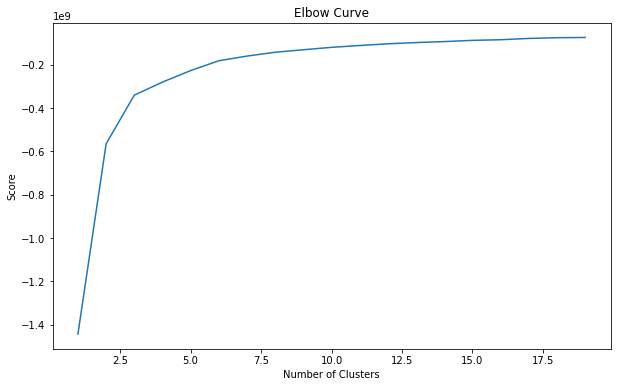

In [15]:
n_cluster = range(1, 20)
kmeans = [KMeans(n_clusters=i).fit(df) for i in n_cluster]
scores = [kmeans[i].score(df) for i in range(len(kmeans))]

fig, ax = plt.subplots(figsize=(10,6))
ax.plot(n_cluster, scores)
plt.xlabel('Number of Clusters')
plt.ylabel('Score')
plt.title('Elbow Curve')
plt.show()

In [11]:
len(c1.columns)

96

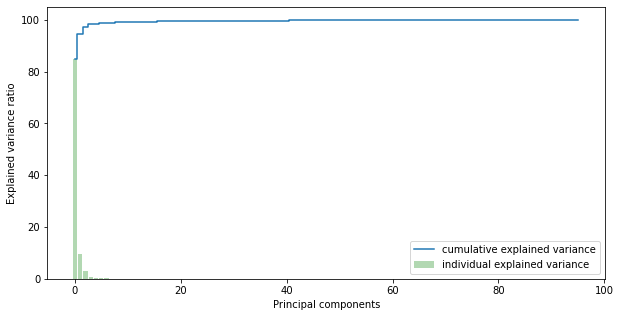

In [16]:
X_std = StandardScaler().fit_transform(df)
mean_vec = np.mean(X_std, axis=0)
cov_mat = np.cov(X_std.T)
eig_vals, eig_vecs = np.linalg.eig(cov_mat)
eig_pairs = [ (np.abs(eig_vals[i]),eig_vecs[:,i]) for i in range(len(eig_vals))]
eig_pairs.sort(key = lambda x: x[0], reverse= True)
tot = sum(eig_vals)
var_exp = [(i/tot)*100 for i in sorted(eig_vals, reverse=True)] # Individual explained variance
cum_var_exp = np.cumsum(var_exp) # Cumulative explained variance

plt.figure(figsize=(10, 5))
plt.bar(range(len(var_exp)), var_exp, alpha=0.3, align='center', label='individual explained variance', color = 'g')
plt.step(range(len(cum_var_exp)), cum_var_exp, where='mid',label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc='best')
plt.show();

In [29]:
# df['date_time_int'] = c1.date.astype(np.int64)
# df

In [ ]:
# Resample the entire dataset by daily average
rollmean = df.resample(rule='D').mean()
rollstd = df.resample(rule='D').std()
# Plot time series for each sensor with its mean and standard deviation
for name in df.columns:
    _ = plt.figure(figsize=(50,3))
    _ = plt.plot(df[name], color='blue', label='Original')
    _ = plt.plot(rollmean[name], color='red', label='Rolling Mean')
    _ = plt.plot(rollstd[name], color='black', label='Rolling Std' )
    _ = plt.legend(loc='best')
    _ = plt.title(name)
    plt.show()

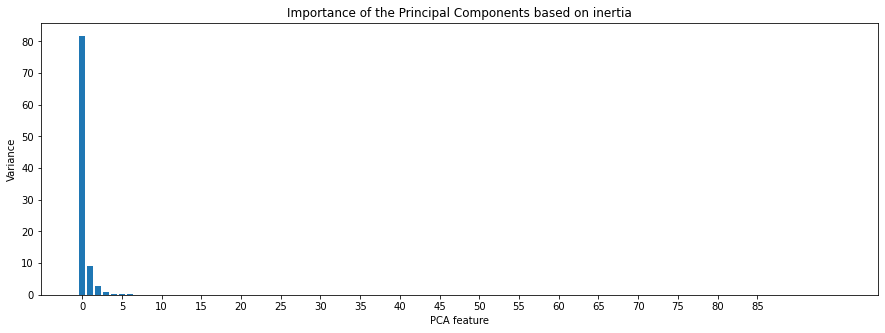

In [42]:
#  Standardize/scale the dataset and apply PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
# Extract the names of the numerical columns
names=df.columns
x = df[names]
scaler = StandardScaler()
pca = PCA()
pipeline = make_pipeline(scaler, pca)
pipeline.fit(x)
# Plot the principal components against their inertia
features = range(pca.n_components_)
_ = plt.figure(figsize=(15, 5))
_ = plt.bar(features, pca.explained_variance_)
_ = plt.xlabel('PCA feature')
_ = plt.ylabel('Variance')
_ = plt.xticks(np.arange(0,90,5))
_ = plt.title("Importance of the Principal Components based on inertia")
plt.show()

In [43]:
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(x)
principalDf = pd.DataFrame(data = principalComponents, columns = ['pc1', 'pc2'])

In [46]:
from statsmodels.tsa.stattools import adfuller
# Run Augmented Dickey Fuller Test
result = adfuller(principalDf['pc1'])
# Print p-value
print(result[1])
# almost stationary (p_value<0.05 -> data is stationary)

0.07574853935299491


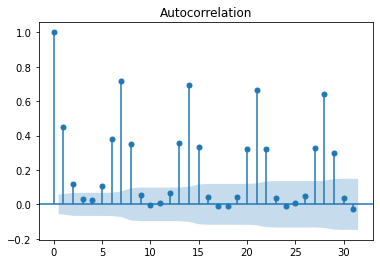

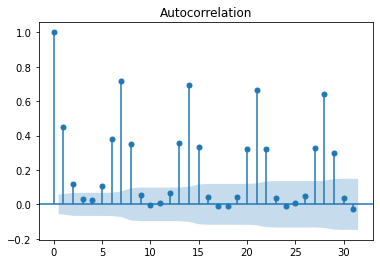

In [53]:
# Plot ACF
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(principalDf['pc1'], lags=20, alpha=0.05)

In [83]:
# df

In [79]:
# CLUSTERING

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10, random_state=42)
kmeans.fit(principalDf.values)
labels = kmeans.predict(principalDf.values)
unique_elements, counts_elements = np.unique(labels, return_counts=True)
clusters = np.asarray((unique_elements, counts_elements))
# Write a function that calculates distance between each point and the centroid of the closest cluster
def getDistanceByPoint(data, model):
    """ Function that calculates the distance between a point and centroid of a cluster, 
            returns the distances in pandas series"""
    distance = []
    for i in range(0,len(data)):
        Xa = np.array(data.loc[i])
        Xb = model.cluster_centers_[model.labels_[i]-1]
        distance.append(np.linalg.norm(Xa-Xb))
    return pd.Series(distance, index=data.index)
# Assume that 1% of the entire data set are anomalies 
outliers_fraction = 0.01
# get the distance between each point and its nearest centroid. The biggest distances are considered as anomaly
distance = getDistanceByPoint(principalDf, kmeans)
# number of observations that equate to the 1% of the entire data set
number_of_outliers = int(outliers_fraction*len(distance))
# Take the minimum of the largest 1% of the distances as the threshold
threshold = distance.nlargest(number_of_outliers).min()
# anomaly1 contain the anomaly result of the above method Cluster (0:normal, 1:anomaly) 
principalDf['anomaly1'] = (distance >= threshold).astype(int)

In [113]:
# df

In [ ]:
df['anomaly1'] = pd.Series(principalDf['anomaly1'].values, index=df.index)
for i in df.columns:
    a = df.loc[df['anomaly1'] == 1] #anomaly
    _ = plt.figure(figsize=(100,6))
    _ = plt.plot(df[i], color='blue', label='Normal')
    _ = plt.plot(a[i], linestyle='none', marker='X', color='red', markersize=12, label='Anomaly')
    _ = plt.xlabel('Date and Time')
    _ = plt.ylabel('kwh')
    _ = plt.title(i + 'Anomalies')
    _ = plt.legend(loc='best')
    plt.show();

In [116]:
# Import IsolationForest


from sklearn.ensemble import IsolationForest
# Assume that 1% of the entire data set are anomalies
 
outliers_fraction = 0.01
model =  IsolationForest(contamination=outliers_fraction)
model.fit(principalDf.values) 
principalDf['anomaly2'] = pd.Series(model.predict(principalDf.values))
# visualization
df['anomaly2'] = pd.Series(principalDf['anomaly2'].values, index=df.index)
# for i in df.columns:
#     a = df.loc[df['anomaly2'] == -1] #anomaly
#     _ = plt.figure(figsize=(100,6))
#     _ = plt.plot(df[i], color='blue', label='Normal')
#     _ = plt.plot(a[i], linestyle='none', marker='X', color='red', markersize=12, label='Anomaly')
#     _ = plt.xlabel('Date and Time')
#     _ = plt.ylabel('kwh')
#     _ = plt.title(i+'Anomalies')
#     _ = plt.legend(loc='best')
#     plt.show();

In [117]:
print(df['anomaly1'].value_counts())
print(df['anomaly2'].value_counts())

0    1207
1      12
Name: anomaly1, dtype: int64
 1    1206
-1      13
Name: anomaly2, dtype: int64


In [118]:
df.loc[df['anomaly2'] == -1]

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15,Q16,Q17,Q18,Q19,Q20,Q21,Q22,Q23,Q24,Q25,Q26,Q27,Q28,Q29,Q30,Q31,Q32,Q33,Q34,Q35,Q36,Q37,Q38,Q39,Q40,Q41,Q42,Q43,Q44,Q45,Q46,Q47,Q48,Q49,Q50,Q51,Q52,Q53,Q54,Q55,Q56,Q57,Q58,Q59,Q60,Q61,Q62,Q63,Q64,Q65,Q66,Q67,Q68,Q69,Q70,Q71,Q72,Q73,Q74,Q75,Q76,Q77,Q78,Q79,Q80,Q81,Q82,Q83,Q84,Q85,Q86,Q87,Q88,Q89,Q90,Q91,Q92,Q93,Q94,Q95,Q96,anomaly1,anomaly2
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-04-06,5,6,5,6,6,6,7,6,5,6,5,5,5,5,5,5,6,6,5,4,5,4,4,5,4,4,5,7,5,4,4,4,4,5,3,5,4,6,6,4,4,3,4,4,5,3,5,3,6,6,4,4,4,4,4,4,4,4,4,6,5,4,4,4,4,4,4,4,4,5,6,4,4,5,4,4,4,4,4,5,7,5,5,4,4,4,5,4,4,4,5,4,4,5,7,6,1,-1
2018-04-08,6,5,6,6,6,5,6,6,5,6,8,8,6,6,5,6,5,6,5,4,5,5,7,7,5,4,5,4,5,4,5,4,4,4,4,4,7,6,5,4,4,4,4,4,4,4,4,4,4,4,6,7,5,4,4,4,4,4,4,4,4,4,3,4,3,7,6,4,3,4,4,4,4,4,4,4,3,4,4,6,6,5,4,4,4,4,4,4,4,4,4,4,4,6,7,5,1,-1
2018-11-05,7,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,-1
2018-11-19,10,11,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,-1
2018-11-30,244,238,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,-1
2018-12-30,8,7,8,7,9,7,8,8,7,8,8,8,8,8,8,7,7,9,8,8,7,7,7,7,6,7,8,6,7,7,7,7,7,7,7,6,7,6,6,6,7,6,6,6,5,4,5,4,5,4,5,4,4,4,5,4,5,4,4,5,4,5,4,4,4,5,4,5,4,5,5,6,6,7,7,6,6,7,6,6,7,6,5,6,6,5,6,6,5,6,5,6,6,6,6,6,1,-1
2019-01-01,7,8,7,8,7,8,8,8,7,8,8,8,8,7,8,8,8,7,8,6,6,5,6,6,5,6,5,6,6,5,6,5,6,5,4,5,5,5,5,4,5,4,4,5,4,5,5,4,5,5,5,5,5,5,5,5,4,5,5,4,5,4,4,4,5,4,4,4,4,4,5,5,6,6,5,5,6,6,5,5,6,5,5,5,6,5,5,5,6,5,5,6,5,7,8,8,1,-1
2019-04-26,10,10,10,9,9,10,9,9,9,8,9,9,9,9,8,7,8,8,8,8,7,7,7,7,7,7,7,6,6,5,5,4,5,5,4,5,4,5,6,4,5,4,5,4,5,5,4,4,5,4,5,5,4,5,4,5,4,5,4,5,5,4,5,4,5,5,4,5,4,5,5,4,5,4,5,4,5,4,5,5,4,5,6,5,7,6,6,6,6,6,7,7,7,8,7,8,1,-1
2019-04-28,8,8,8,8,8,8,8,8,8,8,7,8,8,8,8,8,8,7,8,8,8,7,7,6,6,7,6,5,6,6,5,5,6,5,5,5,5,6,6,5,5,5,5,5,5,5,5,5,4,5,5,5,5,5,6,5,5,5,5,5,5,5,5,5,5,5,5,5,4,5,5,5,4,5,5,5,5,5,5,5,5,5,6,6,7,7,6,6,7,7,6,8,7,8,7,8,1,-1
